# House Prices - Advanced Regression Techniques

<img src='https://www.kaggle.com/competitions/5407/images/header'>

## Dataset Description

**File descriptions**

- train.csv - the training set
- test.csv - the test set
- data_description.txt - full description of each column, originally prepared by Dean De Cock but lightly edited to match the column names used here
- sample_submission.csv - a benchmark submission from a linear regression on year and month of sale, lot square footage, and number of bedrooms

**Data fields**

Here's a brief version of what you'll find in the data description file.

- SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
- MSSubClass: The building class
- MSZoning: The general zoning classification
- LotFrontage: Linear feet of street connected to property
- LotArea: Lot size in square feet
- Street: Type of road access
- Alley: Type of alley access
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- LandSlope: Slope of property
- Neighborhood: Physical locations within Ames city limits
- Condition1: Proximity to main road or railroad
- Condition2: Proximity to main road or railroad (if a second is present)
- BldgType: Type of dwelling
- HouseStyle: Style of dwelling
- OverallQual: Overall material and finish quality
- OverallCond: Overall condition rating
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date
- RoofStyle: Type of roof
- RoofMatl: Roof material
- Exterior1st: Exterior covering on house
- Exterior2nd: Exterior covering on house (if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Exterior material quality
- ExterCond: Present condition of the material on the exterior
- Foundation: Type of foundation
- BsmtQual: Height of the basement
- BsmtCond: General condition of the basement
- BsmtExposure: Walkout or garden level basement walls
- BsmtFinType1: Quality of basement finished area
- BsmtFinSF1: Type 1 finished square feet
- BsmtFinType2: Quality of second finished area (if present)
- BsmtFinSF2: Type 2 finished square feet
- BsmtUnfSF: Unfinished square feet of basement area
- TotalBsmtSF: Total square feet of basement area
- Heating: Type of heating
- HeatingQC: Heating quality and condition
- CentralAir: Central air conditioning
- Electrical: Electrical system
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- BsmtFullBath: Basement full bathrooms
- BsmtHalfBath: Basement half bathrooms
- FullBath: Full bathrooms above grade
- HalfBath: Half baths above grade
- Bedroom: Number of bedrooms above basement level
- Kitchen: Number of kitchens
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
- Functional: Home functionality rating
- Fireplaces: Number of fireplaces
- FireplaceQu: Fireplace quality
- GarageType: Garage location
- GarageYrBlt: Year garage was built
- GarageFinish: Interior finish of the garage
- GarageCars: Size of garage in car capacity
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- PavedDrive: Paved driveway
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet
- PoolArea: Pool area in square feet
- PoolQC: Pool quality
- Fence: Fence quality
- MiscFeature: Miscellaneous feature not covered in other categories
- MiscVal: $Value of miscellaneous feature
- MoSold: Month Sold
- YrSold: Year Sold
- SaleType: Type of sale
- SaleCondition: Condition of sale

## Aim & Target 

**Aim**

The primary goal of this competition is to predict the final price of residential homes in Ames, Iowa, using a comprehensive dataset of 79 explanatory variables. This project serves as a technical benchmark for mastering advanced regression techniques beyond simple linear models. By analyzing diverse features like square footage, neighborhood, and build quality, the aim is to uncover the specific factors that most significantly influence property valuation. Ultimately, the project demonstrates an ability to transform raw, high-dimensional data into a high-precision predictive tool.

**Target**

The specific target is to minimize the error between the predicted house prices and the actual sale prices, measured by the Root Mean Squared Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price. Taking the log ensures that errors in predicting expensive houses and cheap houses affect the final score equally. To achieve a top-tier leaderboard position, the model must handle complex preprocessing tasks, such as sophisticated missing value imputation and non-linear feature engineering. The final output is a submission file containing the predicted prices for nearly 1,500 test properties.

## Importing Libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns',90) 

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Reading Dataset & Dataframe Generation

In [2]:
df=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Exploratory Data Analysis

In [4]:
df.shape

(1460, 81)

In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

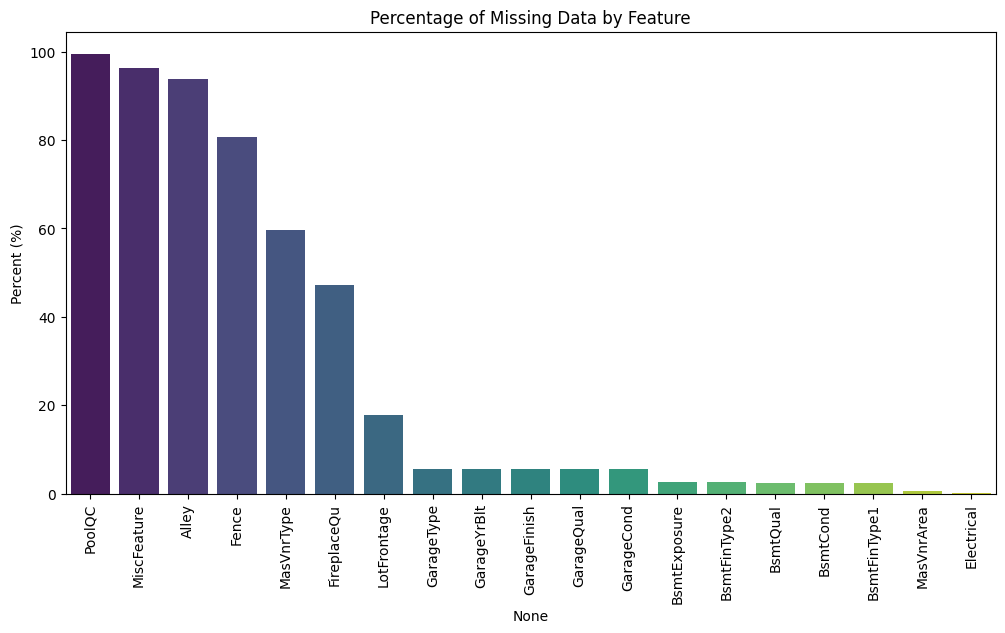

              Count    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247
BsmtCond         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the percentage of missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_percent}).sort_values(by='Percent', ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y=missing_df['Percent'], palette='viridis')
plt.xticks(rotation=90)
plt.title('Percentage of Missing Data by Feature')
plt.ylabel('Percent (%)')
plt.show()

print(missing_df)

## Data Imputation

In [8]:
# A. Categorical columns where NaN means "None"
cols_fillna_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_fillna_none:
    df[col] = df[col].fillna('None')

In [9]:
# B. Numerical columns where NaN means 0
cols_fillna_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
    'BsmtHalfBath', 'MasVnrArea'
]
for col in cols_fillna_zero:
    df[col] = df[col].fillna(0)

In [10]:
# C. LotFrontage & Electrical
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [11]:
# Pre-Encoding Ordinal Features: We must convert the strings to numbers now so we can use them in our "Super Variable" formulas - Feature Engineering

# Mapping quality strings to numbers so we can do math

qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}

# We must map these BEFORE calculating Super Variables
ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
            'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in ord_cols:
    df[col] = df[col].map(qual_map).fillna(0)

df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map).fillna(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Feature Engineering 

In [13]:
# Creating "Super Variables": We combine the individual parts of the house into logic-based sections to reduce the total feature count and eliminate noise.

# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Total Bathrooms
df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                   df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

# 3. Time-Based Features
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

# 4. Total Porch/Outdoor Area
df['TotalPorchSF'] = (df['WoodDeckSF'] + df['OpenPorchSF'] + 
                      df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])

# 5. Garage Performance
df['GarageScore'] = df['GarageCars'] * df['GarageArea']

# 6. Basement Score
df['BasementScore'] = (df['TotalBsmtSF'] * df['BsmtQual']) + (df['BsmtFinSF1'] * df['BsmtFinType1'])

# 7. Exterior Quality
df['ExteriorScore'] = df['ExterQual'] + df['ExterCond']

# 8. Luxury Score
df['HasPool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
df['LuxuryScore'] = (df['Fireplaces'] * df['FireplaceQu']) + df['HasPool']

# 9. Lot & Location Utility
df['LotScore'] = np.log1p(df['LotArea']) * df['LotConfig'].apply(lambda x: 1.1 if x == 'CulDSac' else 1.0)

# 10. Total Rooms Above Ground
df['TotalAbvGrdRooms'] = df['TotRmsAbvGrd'] + df['BedroomAbvGr'] + df['KitchenAbvGr']

# 11. Overall Score (Consolidating Qual, Cond, and Functionality)
df['OverallScore'] = df['OverallQual'] + df['OverallCond'] + df['Functional'].map(
    {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
).fillna(0)

In [14]:
# We remove the original columns to prevent the model from getting confused by duplicate information (multicollinearity).

cols_to_drop = [
    # 1. Basic Info
    'Id', 
    
    # 2. Area/Space (Now in TotalSF and TotalAbvGrdRooms)
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'TotRmsAbvGrd', 'BedroomAbvGr', 'KitchenAbvGr',
    
    # 3. Bathrooms (Now in TotalBath)
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    
    # 4. Time/Age (Now in HouseAge and RemodAge)
    'YearBuilt', 'YearRemodAdd', 
    
    # 5. Outdoor/Porch (Now in TotalPorchSF)
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    
    # 6. Garage (Now in GarageScore)
    'GarageCars', 'GarageArea',
    
    # 7. Basement (Now in BasementScore)
    'BsmtQual', 'BsmtFinSF1', 'BsmtFinType1', 'BsmtFinSF2', 'BsmtFinType2', 'BsmtUnfSF',
    
    # 8. Exterior (Now in ExteriorScore)
    'ExterQual', 'ExterCond',
    
    # 9. Luxury (Now in LuxuryScore)
    'Fireplaces', 'FireplaceQu', 'PoolArea', 'PoolQC',
    
    # 10. General Health (Now in OverallScore)
    'OverallQual', 'OverallCond', 'Functional',
    
    # 11. Redundant/Low Variance (99% same value for all houses)
    'Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating', 'LotArea'
]

# Executing the drop
df.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

print(f"Cleanup complete! Variables remaining: {len(df.columns)}")

Cleanup complete! Variables remaining: 52


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MSSubClass        1460 non-null   int64  
 1   MSZoning          1460 non-null   object 
 2   LotFrontage       1460 non-null   float64
 3   Alley             1460 non-null   object 
 4   LotShape          1460 non-null   object 
 5   LandContour       1460 non-null   object 
 6   LotConfig         1460 non-null   object 
 7   LandSlope         1460 non-null   object 
 8   Neighborhood      1460 non-null   object 
 9   Condition1        1460 non-null   object 
 10  BldgType          1460 non-null   object 
 11  HouseStyle        1460 non-null   object 
 12  RoofStyle         1460 non-null   object 
 13  Exterior1st       1460 non-null   object 
 14  Exterior2nd       1460 non-null   object 
 15  MasVnrType        1460 non-null   object 
 16  MasVnrArea        1460 non-null   float64


## Model Development

In [16]:
# 1. Target Variable Transformation
# We use log1p to normalize the price distribution
if 'SalePrice' in df.columns:
    df['SalePrice'] = np.log1p(df['SalePrice'])

# 2. Convert Categoricals to Dummies
# This turns the 25 'object' columns into 0s and 1s
df_final = pd.get_dummies(df)

print(f"Final Preprocessed Shape: {df_final.shape}")

Final Preprocessed Shape: (1460, 196)


In [17]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Prepare X and y
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

In [18]:
# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# 3. Fit LassoCV (It automatically finds the best penalty 'alpha')
lasso = LassoCV(alphas=[0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01], 
                max_iter=50000, cv=10)
lasso.fit(X_train, y_train)

LassoCV(alphas=[0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01], cv=10,
        max_iter=50000)

In [20]:
# 4. Predict and Evaluate
y_pred = lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [21]:
print(f"Best Alpha: {lasso.alpha_}")
print(f"Lasso RMSE (Log Scale): {rmse:.5f}")

Best Alpha: 0.001
Lasso RMSE (Log Scale): 0.14420


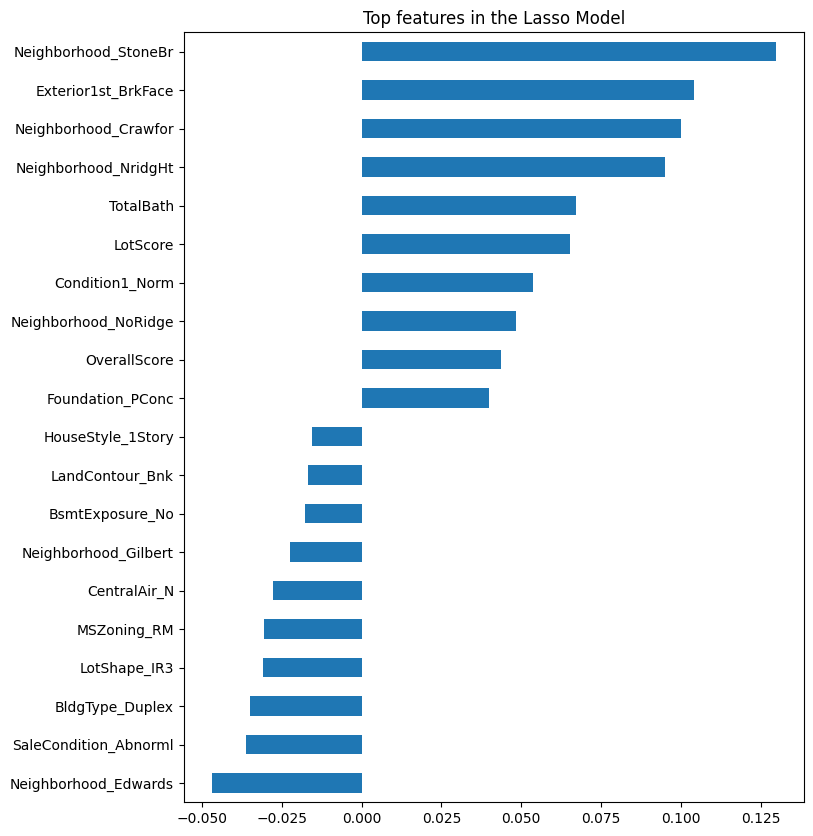

In [22]:
# Feature Importance 

# Look at the coefficients
coef = pd.Series(lasso.coef_, index = X.columns)
imp_coef = pd.concat([coef.sort_values().head(10),
                     coef.sort_values().tail(10)])

plt.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Top features in the Lasso Model")
plt.show()

In [23]:
import pickle

# Save the trained Lasso model
with open('lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso, f)

# Save the list of feature names (the 196 columns)
# This is CRITICAL because pd.get_dummies can produce different shapes on new data
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

print("Model and Columns saved successfully for Hugging Face!")

Model and Columns saved successfully for Hugging Face!


## Kaggle Submission

In [24]:
import pandas as pd
import numpy as np

# 1. LOAD TEST DATA
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
test_id = test_df['Id'] # Save this for the final CSV

# --- STEP 1: FILLING MISSING VALUES (TEST SET) ---
cols_fillna_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cols_fillna_none:
    test_df[col] = test_df[col].fillna('None')

cols_fillna_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
                    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
                    'BsmtHalfBath', 'MasVnrArea']
for col in cols_fillna_zero:
    test_df[col] = test_df[col].fillna(0)

test_df["LotFrontage"] = test_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
test_df['Electrical'] = test_df['Electrical'].fillna(test_df['Electrical'].mode()[0])

# --- STEP 2: MAPPING (Ordinal to Numerical) ---
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}

ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
            'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in ord_cols:
    test_df[col] = test_df[col].map(qual_map).fillna(0)

test_df['BsmtFinType1'] = test_df['BsmtFinType1'].map(fin_map).fillna(0)

# --- STEP 3: 11 SUPER VARIABLES (TEST SET) ---
test_df['TotalSF'] = test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF']
test_df['TotalBath'] = (test_df['FullBath'] + (0.5 * test_df['HalfBath']) +
                        test_df['BsmtFullBath'] + (0.5 * test_df['BsmtHalfBath']))
test_df['HouseAge'] = test_df['YrSold'] - test_df['YearBuilt']
test_df['RemodAge'] = test_df['YrSold'] - test_df['YearRemodAdd']
test_df['IsRemodeled'] = (test_df['YearBuilt'] != test_df['YearRemodAdd']).astype(int)
test_df['TotalPorchSF'] = (test_df['WoodDeckSF'] + test_df['OpenPorchSF'] + 
                           test_df['EnclosedPorch'] + test_df['3SsnPorch'] + test_df['ScreenPorch'])
test_df['GarageScore'] = test_df['GarageCars'] * test_df['GarageArea']
test_df['BasementScore'] = (test_df['TotalBsmtSF'] * test_df['BsmtQual']) + (test_df['BsmtFinSF1'] * test_df['BsmtFinType1'])
test_df['ExteriorScore'] = test_df['ExterQual'] + test_df['ExterCond']
test_df['HasPool'] = test_df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
test_df['LuxuryScore'] = (test_df['Fireplaces'] * test_df['FireplaceQu']) + test_df['HasPool']
test_df['LotScore'] = np.log1p(test_df['LotArea']) * test_df['LotConfig'].apply(lambda x: 1.1 if x == 'CulDSac' else 1.0)
test_df['TotalAbvGrdRooms'] = test_df['TotRmsAbvGrd'] + test_df['BedroomAbvGr'] + test_df['KitchenAbvGr']
test_df['OverallScore'] = test_df['OverallQual'] + test_df['OverallCond'] + test_df['Functional'].map(
    {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
).fillna(0)

# --- STEP 4: CLEAN PURGE & DUMMIES ---
cols_to_drop = [
    'Id', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'TotalBsmtSF', 
    '1stFlrSF', '2ndFlrSF', 'YearBuilt', 'YearRemodAdd', 'WoodDeckSF', 
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'GarageCars', 
    'GarageArea', 'BsmtQual', 'BsmtFinSF1', 'BsmtFinType1', 'ExterQual', 
    'ExterCond', 'Fireplaces', 'FireplaceQu', 'PoolArea', 'LotArea', 
    'TotRmsAbvGrd', 'BedroomAbvGr', 'KitchenAbvGr', 'OverallQual', 
    'OverallCond', 'Functional', 'Street', 'Utilities', 'Condition2', 
    'RoofMatl', 'Heating', 'LowQualFinSF'
]
test_df.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

# One-Hot Encoding
test_df_final = pd.get_dummies(test_df)

# --- STEP 5: ALIGNING COLUMNS (The most important part) ---
# Ensure test set has the exact same columns as train set (X)
# X is the training features we used for lasso.fit()
final_columns = X.columns # From your training block
test_df_final = test_df_final.reindex(columns=final_columns, fill_value=0)

# --- STEP 6: PREDICTION & SUBMISSION ---
# 1. Predict (Result is in Log scale)
log_preds = lasso.predict(test_df_final)

# 2. Exponentiate back to Dollars
final_prices = np.expm1(log_preds)

# 3. Create CSV
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_prices
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission_kaggle.csv' created successfully!")

Submission file 'submission_kaggle.csv' created successfully!


In [25]:
from IPython.display import FileLink

display(FileLink('submission.csv'))
display(FileLink('lasso_model.pkl'))
display(FileLink('model_columns.pkl'))

/kaggle/working/submission.csv

/kaggle/working/lasso_model.pkl

/kaggle/working/model_columns.pkl

## Conclusion 

The core of this project was built on the most critical phase of the data science workflow: Feature Engineering. By distilling the noise from 81 raw variables into 11 logic-driven "Super Variables," we reduced model complexity while standardizing predictive power.

Our Lasso Regression model achieved a solid 0.14420 RMSE, and the coefficient analysis proved that our engineered metrics—specifically OverallScore, TotalSF, and TotalBath—are the strongest signals for determining house value. Ultimately, we didn't just clean the data; we restructured it using domain expertise. This approach resulted in a high-performing, sustainable prediction pipeline that is both competitive on the Kaggle leaderboard and ready for production on platforms like Hugging Face.